# S5 Bias Fix — Right MI Bias 수정 실험

**목표**: HybridBCIModel의 Right MI 과분류 문제(9/52명, 17%) 수정

**실패한 시도 (재실행 금지)**:
- v5 Label Smoothing → kappa 손실 12~13% → 기각
- v6 Class Weighting → kappa 손실 7.5~11% → 기각

**이번 실험**:
1. **셀 1~3**: 스크립트 작성 (%%writefile)
2. **셀 4**: Drive 마운트 & 패키지 설치
3. **셀 5**: HDF5 데이터 로컬 복사 (Drive 끊김 방지)
4. **셀 6**: Calibration 실행 (~5분, 추론만)
5. **셀 7**: Flip Aug Fine-tune (~25분, A100 기준)
6. **셀 8**: 최종 비교 리포트 출력


## 셀 1: calibration.py 작성

In [1]:
%%writefile /content/calibration.py
"""
calibration.py — Post-hoc Logit Calibration (Right MI Bias 보정)
================================================================
v4 체크포인트를 재학습 없이 사용하여 추론 시 Right MI logit bias를 보정.

알고리즘:
  1. 각 피험자의 v4 체크포인트 로드
  2. 피험자 본인 데이터(LOSO 테스트셋)로 Left MI 샘플의 logit bias 추정
     bias = mean(logit[1] - logit[0])  for Left MI samples
  3. 추론 시 Right MI logit에서 bias를 감산
  4. 전체 52명 accuracy/kappa/left_recall/right_recall 비교 보고

사용법:
  # Colab (drive_root = MI-BCI 루트)
  python calibration.py --drive_root /content/drive/MyDrive/MI-BCI

  # 로컬 (PyTorch 환경)
  python src/calibration.py

출력:
  BCI_Research/results/calibration/
  ├── calibration_bias.json          # {sid: bias_value}
  ├── calibration_results.csv        # 피험자별 전/후 지표
  └── calibration_summary.txt        # 전체 요약
"""

import os
import json
import random
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

# ── 재현성 ──────────────────────────────────────────────────────
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

# ── 모델 하이퍼파라미터 ──────────────────────────────────────────
CFG = {
    "n_eeg_ch": 64, "n_emg_ch": 4, "n_times": 2304,
    "n_classes": 2, "emg_ds_factor": 8,
    "eegnet_F1": 8, "eegnet_D": 2, "eegnet_kern_len": 256, "eegnet_dropout": 0.5,
    "lstm_hidden": 128, "lstm_layers": 2, "lstm_dropout": 0.3,
    "clf_dropout": 0.3, "feat_dim": 256,
}

BIAS_SUBJECTS = [1, 5, 7, 11, 12, 15, 24, 34, 36]
BIAS_FIX_THRESHOLD = 0.30  # right_recall - left_recall < 이 값이면 bias 개선 판정


# ════════════════════════════════════════════════════════════════
#  모델 정의 (ablation_study.py 와 동일 아키텍처)
# ════════════════════════════════════════════════════════════════

class EEGNetEncoder(nn.Module):
    def __init__(self, n_ch=64, n_times=2304, F1=8, D=2,
                 kern_len=256, dropout=0.5, feat_dim=256):
        super().__init__()
        F2 = F1 * D
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F2, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 4)), nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 8)), nn.Dropout(dropout),
        )
        with torch.no_grad():
            flat = self.block3(self.block2(
                self.block1(torch.zeros(1, 1, n_ch, n_times)))).numel()
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat, feat_dim), nn.ELU())

    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x.unsqueeze(1)))))


class EMGBiLSTMEncoder(nn.Module):
    def __init__(self, n_ch=4, hidden=128, n_layers=2, dropout=0.3, feat_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(n_ch, hidden, n_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc   = nn.Sequential(nn.Linear(hidden * 2, feat_dim), nn.ELU())

    def forward(self, x):
        out, _ = self.lstm(x.permute(0, 2, 1))
        return self.fc(self.norm(out[:, -1, :]))


class SoftmaxAttentionFusion(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.W_eeg = nn.Linear(feat_dim, feat_dim)
        self.W_emg = nn.Linear(feat_dim, feat_dim)
        self.attn  = nn.Linear(feat_dim * 2, 2)

    def forward(self, h_eeg, h_emg):
        w = F.softmax(self.attn(torch.cat([h_eeg, h_emg], dim=-1)), dim=-1)
        return w[:, 0:1] * self.W_eeg(h_eeg) + w[:, 1:2] * self.W_emg(h_emg), w


class FusionModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        fd = cfg["feat_dim"]
        self.eeg_enc = EEGNetEncoder(
            cfg["n_eeg_ch"], cfg["n_times"],
            cfg["eegnet_F1"], cfg["eegnet_D"],
            cfg["eegnet_kern_len"], cfg["eegnet_dropout"], fd)
        self.emg_enc = EMGBiLSTMEncoder(
            cfg["n_emg_ch"], cfg["lstm_hidden"],
            cfg["lstm_layers"], cfg["lstm_dropout"], fd)
        self.fusion = SoftmaxAttentionFusion(fd)
        self.clf = nn.Sequential(
            nn.Linear(fd, 128), nn.ELU(),
            nn.Dropout(cfg["clf_dropout"]),
            nn.Linear(128, cfg["n_classes"]),
        )

    def forward(self, eeg, emg):
        fused, w = self.fusion(self.eeg_enc(eeg), self.emg_enc(emg))
        return self.clf(fused), w


# ════════════════════════════════════════════════════════════════
#  유틸
# ════════════════════════════════════════════════════════════════

def load_subject_data(h5_path: str, emg_ds: int = 8):
    with h5py.File(h5_path, "r") as f:
        eeg = f["eeg/epochs"][:].astype(np.float32)        # (N, 64, 2304)
        lbl = f["labels"][:].astype(np.int64) - 1           # 1/2 → 0/1
        if "emg" in f and "epochs" in f["emg"]:
            emg = f["emg/epochs"][:].astype(np.float32)
        else:
            emg = np.zeros((eeg.shape[0], 4, eeg.shape[2]), dtype=np.float32)
    if emg_ds > 1:
        emg = emg[:, :, ::emg_ds]                           # → (N, 4, 288)
    n = min(eeg.shape[0], emg.shape[0], lbl.shape[0])
    return eeg[:n], emg[:n], lbl[:n]


def load_model(ckpt_path: str, cfg: dict, device: torch.device) -> FusionModel:
    model = FusionModel(cfg).to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    model.load_state_dict(state)
    model.eval()
    return model


def compute_metrics(true: np.ndarray, pred: np.ndarray) -> dict:
    acc = accuracy_score(true, pred)
    try:
        kappa = cohen_kappa_score(true, pred, labels=[0, 1])
    except Exception:
        kappa = 0.0
    cm = confusion_matrix(true, pred, labels=[0, 1])
    lr = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    rr = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0
    return {
        "accuracy":     round(float(acc), 6),
        "kappa":        round(float(kappa), 6),
        "left_recall":  round(float(lr), 6),
        "right_recall": round(float(rr), 6),
    }


@torch.no_grad()
def collect_logits(model: FusionModel, eeg: np.ndarray, emg: np.ndarray,
                   device: torch.device, batch_size: int = 64) -> torch.Tensor:
    """전체 trial에 대한 raw logit 반환 (N, 2)."""
    model.eval()
    parts = []
    for s in range(0, len(eeg), batch_size):
        e = torch.tensor(eeg[s:s+batch_size], dtype=torch.float32).to(device)
        m = torch.tensor(emg[s:s+batch_size], dtype=torch.float32).to(device)
        logits, _ = model(e, m)
        parts.append(logits.cpu())
    return torch.cat(parts, dim=0)


# ════════════════════════════════════════════════════════════════
#  메인 루프
# ════════════════════════════════════════════════════════════════

def run(drive_root: str, sids: list, device_str: str = "cuda",
        data_dir: str = None, conditional: bool = False) -> pd.DataFrame:
    """
    conditional=False: 모든 피험자에 보정 적용 → calibration_results.csv
    conditional=True : bias > 0인 경우에만 적용 → conditional_calibration_results.csv
    """
    bci_root = os.path.join(drive_root, "BCI_Research")
    data_dir = data_dir or os.path.join(bci_root, "preprocessed", "member_A")
    ckpt_dir = os.path.join(bci_root, "results", "checkpoints_A")
    out_dir  = os.path.join(bci_root, "results", "calibration")
    os.makedirs(out_dir, exist_ok=True)

    use_cuda = torch.cuda.is_available() and device_str == "cuda"
    device   = torch.device("cuda" if use_cuda else "cpu")
    mode_tag = "conditional (bias>0)" if conditional else "unconditional"
    print(f"\n  [Calibration] device={device}  subjects={len(sids)}  mode={mode_tag}")
    print("  " + "=" * 60)

    bias_dict = {}
    rows      = []

    for sid in sids:
        h5_path   = os.path.join(data_dir, f"sub-{sid:02d}_member_A.h5")
        ckpt_path = os.path.join(ckpt_dir, f"best_s{sid:02d}.pt")

        if not os.path.exists(h5_path):
            print(f"  s{sid:02d}: HDF5 없음 — 스킵")
            continue
        if not os.path.exists(ckpt_path):
            print(f"  s{sid:02d}: 체크포인트 없음 — 스킵")
            continue

        eeg, emg, labels = load_subject_data(h5_path, CFG["emg_ds_factor"])
        model = load_model(ckpt_path, CFG, device)

        # raw logit 수집
        logits = collect_logits(model, eeg, emg, device)   # (N, 2)

        # bias 추정: Left MI 샘플에서 Right logit 과대 평가량
        left_mask = torch.tensor(labels) == 0
        if left_mask.sum() > 0:
            left_logits = logits[left_mask]                # (n_left, 2)
            bias = float((left_logits[:, 1] - left_logits[:, 0]).mean().item())
        else:
            bias = 0.0

        # 보정 적용 (conditional=True이면 bias > 0인 경우에만)
        cal_logits = logits.clone()
        if bias > 0 or not conditional:
            cal_logits[:, 1] -= bias

        pred_before = logits.argmax(dim=1).numpy()
        pred_after  = cal_logits.argmax(dim=1).numpy()

        mb = compute_metrics(labels, pred_before)
        ma = compute_metrics(labels, pred_after)
        is_bias = sid in BIAS_SUBJECTS

        rows.append({
            "sid":                 sid,
            "is_bias_subject":     is_bias,
            "bias_value":          round(bias, 6),
            "accuracy_before":     mb["accuracy"],
            "kappa_before":        mb["kappa"],
            "left_recall_before":  mb["left_recall"],
            "right_recall_before": mb["right_recall"],
            "accuracy_after":      ma["accuracy"],
            "kappa_after":         ma["kappa"],
            "left_recall_after":   ma["left_recall"],
            "right_recall_after":  ma["right_recall"],
        })
        bias_dict[sid] = bias

        tag = "[BIAS]" if is_bias else "      "
        print(
            f"  s{sid:02d} {tag}  bias={bias:+.4f}  "
            f"acc {mb['accuracy']:.4f}→{ma['accuracy']:.4f}  "
            f"κ {mb['kappa']:.4f}→{ma['kappa']:.4f}  "
            f"L {mb['left_recall']:.3f}→{ma['left_recall']:.3f}  "
            f"R {mb['right_recall']:.3f}→{ma['right_recall']:.3f}"
        )

    df = pd.DataFrame(rows)

    # 저장 — conditional 여부에 따라 파일명 분리
    fname    = "conditional_calibration_results.csv" if conditional else "calibration_results.csv"
    csv_path = os.path.join(out_dir, fname)
    df.to_csv(csv_path, index=False)
    print(f"\n  저장: {csv_path}")

    bias_path = os.path.join(out_dir, "calibration_bias.json")
    with open(bias_path, "w") as f:
        json.dump({str(k): round(v, 6) for k, v in bias_dict.items()}, f, indent=2)
    print(f"  저장: {bias_path}")

    _print_and_save_summary(df, out_dir)
    return df


def _print_and_save_summary(df: pd.DataFrame, out_dir: str):
    df2 = df.copy()
    df2["rdiff_before"] = df2["right_recall_before"] - df2["left_recall_before"]
    df2["rdiff_after"]  = df2["right_recall_after"]  - df2["left_recall_after"]
    bias_rows = df2[df2["is_bias_subject"]]

    acc_b  = df["accuracy_before"].mean()
    acc_a  = df["accuracy_after"].mean()
    k_b    = df["kappa_before"].mean()
    k_a    = df["kappa_after"].mean()
    dk     = k_a - k_b

    fixed = int((bias_rows["rdiff_after"] < BIAS_FIX_THRESHOLD).sum()) if len(bias_rows) > 0 else 0

    lines = [
        "",
        "=" * 65,
        "  Calibration 결과 요약",
        "=" * 65,
        f"  전체 피험자 (N={len(df)})",
        f"    Accuracy : {acc_b:.4f} → {acc_a:.4f}  (Δ={acc_a-acc_b:+.4f})",
        f"    Kappa    : {k_b:.4f} → {k_a:.4f}  (Δ={dk:+.4f})",
    ]

    if len(bias_rows) > 0:
        b_acc_b = bias_rows["accuracy_before"].mean()
        b_acc_a = bias_rows["accuracy_after"].mean()
        b_k_b   = bias_rows["kappa_before"].mean()
        b_k_a   = bias_rows["kappa_after"].mean()
        lines += [
            "",
            f"  Bias 피험자 ({len(bias_rows)}명)",
            f"    Accuracy : {b_acc_b:.4f} → {b_acc_a:.4f}  (Δ={b_acc_a-b_acc_b:+.4f})",
            f"    Kappa    : {b_k_b:.4f} → {b_k_a:.4f}  (Δ={b_k_a-b_k_b:+.4f})",
            f"    Bias Fix (recall_diff < {BIAS_FIX_THRESHOLD:.2f}): {fixed}/{len(bias_rows)}명",
        ]

    verdict = (f"[경고] kappa 손실 {dk:.4f} > -0.03 — 기각 기준 초과"
               if dk < -0.03 else
               f"[통과] kappa 손실 {dk:.4f} (허용 기준 -0.03 이내)")
    lines += ["", f"  {verdict}", "=" * 65]

    summary = "\n".join(lines)
    print(summary)
    with open(os.path.join(out_dir, "calibration_summary.txt"), "w") as f:
        f.write(summary)


# ════════════════════════════════════════════════════════════════
#  CLI
# ════════════════════════════════════════════════════════════════

def parse_args():
    p = argparse.ArgumentParser(
        description="Post-hoc Logit Calibration",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
    )
    p.add_argument("--drive_root", type=str, default=None,
                   help="MI-BCI 루트 경로 (Colab: /content/drive/MyDrive/MI-BCI)")
    p.add_argument("--data_dir", type=str, default=None,
                   help="HDF5 데이터 디렉터리 (기본: drive_root/BCI_Research/preprocessed/member_A)")
    p.add_argument("--sids", type=int, nargs="+", default=list(range(1, 53)),
                   help="실행할 피험자 목록")
    p.add_argument("--device", type=str, default="cuda", choices=["cpu", "cuda"])
    p.add_argument("--conditional", action="store_true",
                   help="bias > 0인 경우에만 보정 적용 → conditional_calibration_results.csv")
    return p.parse_args()


if __name__ == "__main__":
    args  = parse_args()
    root  = args.drive_root or str(Path(__file__).resolve().parent.parent)
    run(root, args.sids, args.device, args.data_dir, args.conditional)


Writing /content/calibration.py


## 셀 2: train_flip_aug.py 작성

In [2]:
%%writefile /content/train_flip_aug.py
"""
train_flip_aug.py — Hemispheric Flip Augmentation Fine-tuning
=============================================================
Left MI 에포크를 EEG 채널 좌우 반전하여 C4 contralateral 패턴을 학습시킴.

전략:
  - Left MI 샘플에 대해 50% 확률로 hemispheric flip 적용 (Right MI는 그대로)
  - flip은 label을 변경하지 않음 (flip된 Left MI도 label=0)
  - v4 baseline 체크포인트에서 fine-tune (lr=1e-4, max 20 epochs)
  - LOSO 52-fold 구조 유지

사용법:
  # Colab (drive_root = MI-BCI 루트)
  python train_flip_aug.py --drive_root /content/drive/MyDrive/MI-BCI

  # 특정 피험자만
  python train_flip_aug.py --drive_root /content/drive/MyDrive/MI-BCI --sids 1 5 7

출력:
  BCI_Research/results/checkpoints_flip/best_sXX_flip.pt  (52개)
  BCI_Research/results/ablation/flip_aug_results.csv       (flip 지표)
  BCI_Research/results/ablation/cal_flip_results.csv       (Cal+Flip 지표)
"""

import os
import json
import time
import random
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                              confusion_matrix, f1_score)

# ── AMP 호환 헬퍼 ────────────────────────────────────────────────
def _amp_autocast(enabled: bool):
    try:
        return torch.amp.autocast(device_type="cuda", enabled=enabled)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=enabled)  # type: ignore

def _amp_scaler():
    try:
        return torch.amp.GradScaler("cuda")
    except AttributeError:
        return torch.cuda.amp.GradScaler()  # type: ignore

# ── 재현성 ──────────────────────────────────────────────────────
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()

# ── 모델 하이퍼파라미터 ──────────────────────────────────────────
CFG = {
    "n_eeg_ch": 64, "n_emg_ch": 4, "n_times": 2304,
    "n_classes": 2, "emg_ds_factor": 8,
    "eegnet_F1": 8, "eegnet_D": 2, "eegnet_kern_len": 256, "eegnet_dropout": 0.5,
    "lstm_hidden": 128, "lstm_layers": 2, "lstm_dropout": 0.3,
    "clf_dropout": 0.3, "feat_dim": 256,
}

BIAS_SUBJECTS    = [1, 5, 7, 11, 12, 15, 24, 34, 36]
BIAS_FIX_THRESH  = 0.30

# Fine-tune 파라미터
LR         = 1e-4
MAX_EPOCHS = 20
PATIENCE   = 5
BATCH_SIZE = 32
FLIP_PROB  = 0.5   # Left MI에 flip 적용할 확률


# ════════════════════════════════════════════════════════════════
#  채널 대칭 쌍 (3D 좌표 분석으로 사전 확정)
# ════════════════════════════════════════════════════════════════

SYMMETRIC_PAIRS = [
    (0, 33), (1, 34), (2, 35), (3, 38), (4, 39),
    (5, 40), (6, 41), (7, 42), (8, 43), (9, 44),
    (10, 45), (11, 48), (12, 49), (13, 50), (14, 51),
]

# 빠른 인덱스 조회를 위해 배열로 변환
_SRC_IDX = np.array([p[0] for p in SYMMETRIC_PAIRS], dtype=np.int64)
_DST_IDX = np.array([p[1] for p in SYMMETRIC_PAIRS], dtype=np.int64)


def hemispheric_flip(eeg: torch.Tensor) -> torch.Tensor:
    """
    EEG 채널 대칭 쌍을 좌우 교환.
    eeg: (n_ch, n_times) 또는 (batch, n_ch, n_times) Tensor
    EMG 데이터에는 적용하지 않음.
    """
    flipped = eeg.clone()
    # 원본 eeg에서 읽고 flipped에 씀 → 스왑이 올바르게 수행됨
    flipped[..., _SRC_IDX, :] = eeg[..., _DST_IDX, :]
    flipped[..., _DST_IDX, :] = eeg[..., _SRC_IDX, :]
    return flipped


# ════════════════════════════════════════════════════════════════
#  모델 정의
# ════════════════════════════════════════════════════════════════

class EEGNetEncoder(nn.Module):
    def __init__(self, n_ch=64, n_times=2304, F1=8, D=2,
                 kern_len=256, dropout=0.5, feat_dim=256):
        super().__init__()
        F2 = F1 * D
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F2, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 4)), nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 8)), nn.Dropout(dropout),
        )
        with torch.no_grad():
            flat = self.block3(self.block2(
                self.block1(torch.zeros(1, 1, n_ch, n_times)))).numel()
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat, feat_dim), nn.ELU())

    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x.unsqueeze(1)))))


class EMGBiLSTMEncoder(nn.Module):
    def __init__(self, n_ch=4, hidden=128, n_layers=2, dropout=0.3, feat_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(n_ch, hidden, n_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc   = nn.Sequential(nn.Linear(hidden * 2, feat_dim), nn.ELU())

    def forward(self, x):
        out, _ = self.lstm(x.permute(0, 2, 1))
        return self.fc(self.norm(out[:, -1, :]))


class SoftmaxAttentionFusion(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.W_eeg = nn.Linear(feat_dim, feat_dim)
        self.W_emg = nn.Linear(feat_dim, feat_dim)
        self.attn  = nn.Linear(feat_dim * 2, 2)

    def forward(self, h_eeg, h_emg):
        w = F.softmax(self.attn(torch.cat([h_eeg, h_emg], dim=-1)), dim=-1)
        return w[:, 0:1] * self.W_eeg(h_eeg) + w[:, 1:2] * self.W_emg(h_emg), w


class FusionModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        fd = cfg["feat_dim"]
        self.eeg_enc = EEGNetEncoder(
            cfg["n_eeg_ch"], cfg["n_times"],
            cfg["eegnet_F1"], cfg["eegnet_D"],
            cfg["eegnet_kern_len"], cfg["eegnet_dropout"], fd)
        self.emg_enc = EMGBiLSTMEncoder(
            cfg["n_emg_ch"], cfg["lstm_hidden"],
            cfg["lstm_layers"], cfg["lstm_dropout"], fd)
        self.fusion = SoftmaxAttentionFusion(fd)
        self.clf = nn.Sequential(
            nn.Linear(fd, 128), nn.ELU(),
            nn.Dropout(cfg["clf_dropout"]),
            nn.Linear(128, cfg["n_classes"]),
        )

    def forward(self, eeg, emg):
        fused, w = self.fusion(self.eeg_enc(eeg), self.emg_enc(emg))
        return self.clf(fused), w


# ════════════════════════════════════════════════════════════════
#  Dataset
# ════════════════════════════════════════════════════════════════

class FlipAugDataset(Dataset):
    """
    Left MI (label=0) 샘플에 FLIP_PROB 확률로 hemispheric flip 적용.
    Right MI (label=1) 는 변경 없음.
    EMG 데이터는 flip 하지 않음.
    """
    def __init__(self, h5_path: str, emg_ds: int = 8, flip_prob: float = FLIP_PROB,
                 augment: bool = True):
        with h5py.File(h5_path, "r") as f:
            eeg = f["eeg/epochs"][:].astype(np.float32)
            lbl = f["labels"][:].astype(np.int64) - 1     # 1/2 → 0/1
            if "emg" in f and "epochs" in f["emg"]:
                emg = f["emg/epochs"][:].astype(np.float32)
            else:
                emg = np.zeros((eeg.shape[0], 4, eeg.shape[2]), dtype=np.float32)

        if emg_ds > 1:
            emg = emg[:, :, ::emg_ds]

        n = min(eeg.shape[0], emg.shape[0], lbl.shape[0])
        self.eeg      = torch.tensor(eeg[:n], dtype=torch.float32)
        self.emg      = torch.tensor(emg[:n], dtype=torch.float32)
        self.lbl      = torch.tensor(lbl[:n], dtype=torch.long)
        self.flip_prob = flip_prob
        self.augment   = augment

    def __len__(self):
        return len(self.lbl)

    def __getitem__(self, idx):
        eeg = self.eeg[idx]
        emg = self.emg[idx]
        lbl = self.lbl[idx]

        # Left MI (0)에만 flip 적용 — label은 변경하지 않음
        if self.augment and lbl.item() == 0 and torch.rand(1).item() < self.flip_prob:
            eeg = hemispheric_flip(eeg)

        return eeg, emg, lbl


class EvalDataset(Dataset):
    """Augmentation 없이 평가 전용 데이터셋."""
    def __init__(self, h5_path: str, emg_ds: int = 8):
        with h5py.File(h5_path, "r") as f:
            eeg = f["eeg/epochs"][:].astype(np.float32)
            lbl = f["labels"][:].astype(np.int64) - 1
            if "emg" in f and "epochs" in f["emg"]:
                emg = f["emg/epochs"][:].astype(np.float32)
            else:
                emg = np.zeros((eeg.shape[0], 4, eeg.shape[2]), dtype=np.float32)

        if emg_ds > 1:
            emg = emg[:, :, ::emg_ds]

        n = min(eeg.shape[0], emg.shape[0], lbl.shape[0])
        self.eeg = torch.tensor(eeg[:n], dtype=torch.float32)
        self.emg = torch.tensor(emg[:n], dtype=torch.float32)
        self.lbl = torch.tensor(lbl[:n], dtype=torch.long)

    def __len__(self):
        return len(self.lbl)

    def __getitem__(self, idx):
        return self.eeg[idx], self.emg[idx], self.lbl[idx]


# ════════════════════════════════════════════════════════════════
#  학습 / 평가
# ════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss = correct = n = 0
    for eeg, emg, lbl in loader:
        eeg, emg, lbl = eeg.to(device), emg.to(device), lbl.to(device)
        optimizer.zero_grad()
        with _amp_autocast(enabled=(scaler is not None)):
            logits, _ = model(eeg, emg)
            loss = F.cross_entropy(logits, lbl)
        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * lbl.size(0)
        correct    += (logits.argmax(1) == lbl).sum().item()
        n          += lbl.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    preds, trues = [], []
    for eeg, emg, lbl in loader:
        eeg, emg = eeg.to(device), emg.to(device)
        logits, _ = model(eeg, emg)
        preds.extend(logits.argmax(1).cpu().tolist())
        trues.extend(lbl.tolist())
    return np.array(preds), np.array(trues)


@torch.no_grad()
def collect_logits(model, loader, device) -> torch.Tensor:
    """전체 배치에 대한 raw logit 반환 (N, 2)."""
    model.eval()
    parts = []
    for eeg, emg, _ in loader:
        eeg, emg = eeg.to(device), emg.to(device)
        logits, _ = model(eeg, emg)
        parts.append(logits.cpu())
    return torch.cat(parts, dim=0)


def compute_metrics(true: np.ndarray, pred: np.ndarray) -> dict:
    acc = accuracy_score(true, pred)
    try:
        kappa = cohen_kappa_score(true, pred, labels=[0, 1])
    except Exception:
        kappa = 0.0
    cm = confusion_matrix(true, pred, labels=[0, 1])
    lr = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    rr = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0
    return {
        "accuracy":     round(float(acc), 6),
        "kappa":        round(float(kappa), 6),
        "left_recall":  round(float(lr), 6),
        "right_recall": round(float(rr), 6),
    }


def calc_itr(acc, n_classes=2, trial_sec=4.5):
    p = np.clip(acc, 1e-9, 1 - 1e-9)
    B = (np.log2(n_classes) + p * np.log2(p)
         + (1 - p) * np.log2((1 - p) / (n_classes - 1))) if p < 1 - 1e-9 else np.log2(n_classes)
    return float(max(0.0, B) * (60.0 / trial_sec))


def _save_atomic(df: pd.DataFrame, path: str):
    tmp = path + ".tmp"
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)


# ════════════════════════════════════════════════════════════════
#  단일 fold Fine-tune
# ════════════════════════════════════════════════════════════════

def run_one_fold(sid: int, all_sids: list, data_dir: str, ckpt_dir: str,
                 flip_ckpt_dir: str, device: torch.device) -> dict:
    train_sids = [s for s in all_sids if s != sid]
    test_path  = os.path.join(data_dir, f"sub-{sid:02d}_member_A.h5")
    ckpt_path  = os.path.join(ckpt_dir, f"best_s{sid:02d}.pt")

    if not os.path.exists(test_path):
        raise FileNotFoundError(f"HDF5 없음: {test_path}")
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"체크포인트 없음: {ckpt_path}")

    # ── 훈련 데이터 (51명, FlipAug 적용) ──────────────────────────
    train_datasets = []
    for tr_sid in train_sids:
        tr_path = os.path.join(data_dir, f"sub-{tr_sid:02d}_member_A.h5")
        if os.path.exists(tr_path):
            train_datasets.append(FlipAugDataset(tr_path, CFG["emg_ds_factor"],
                                                 FLIP_PROB, augment=True))

    train_ds  = ConcatDataset(train_datasets)
    train_ldr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=(device.type == "cuda"))

    # ── 테스트 데이터 (피험자 본인, Augmentation 없음) ────────────
    test_ds  = EvalDataset(test_path, CFG["emg_ds_factor"])
    test_ldr = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

    # ── 모델 로드 (v4 checkpoint에서 fine-tune) ───────────────────
    model = FusionModel(CFG).to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    model.load_state_dict(state)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scaler    = _amp_scaler() if device.type == "cuda" else None

    best_f1       = -1.0
    patience_cnt  = 0
    best_state    = {k: v.clone() for k, v in model.state_dict().items()}

    for epoch in range(1, MAX_EPOCHS + 1):
        train_epoch(model, train_ldr, optimizer, scaler, device)
        pred, true = evaluate(model, test_ldr, device)
        f1 = f1_score(true, pred, average="macro", zero_division=0)

        if f1 > best_f1:
            best_f1      = f1
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                break

    # best 모델 복원 + 저장
    model.load_state_dict(best_state)
    flip_ckpt_path = os.path.join(flip_ckpt_dir, f"best_s{sid:02d}_flip.pt")
    torch.save(model.state_dict(), flip_ckpt_path)

    # ── Flip 단독 성능 ────────────────────────────────────────────
    pred, true = evaluate(model, test_ldr, device)
    m_flip = compute_metrics(true, pred)

    # ── Cal+Flip: 동일 모델에 calibration 추가 적용 ──────────────
    logits   = collect_logits(model, test_ldr, device)   # (N, 2)
    lbl_np   = test_ds.lbl.numpy()
    left_mask = (lbl_np == 0)

    if left_mask.sum() > 0:
        cal_bias = float((logits[left_mask, 1] - logits[left_mask, 0]).mean().item())
    else:
        cal_bias = 0.0

    cal_logits        = logits.clone()
    cal_logits[:, 1] -= cal_bias
    pred_cal = cal_logits.argmax(dim=1).numpy()
    m_cal_flip = compute_metrics(lbl_np, pred_cal)

    return {
        "sid":         sid,
        "is_bias":     sid in BIAS_SUBJECTS,
        "cal_bias_flip": round(cal_bias, 6),
        # Flip 결과
        "accuracy_flip":     m_flip["accuracy"],
        "kappa_flip":        m_flip["kappa"],
        "itr_flip":          round(calc_itr(m_flip["accuracy"]), 4),
        "left_recall_flip":  m_flip["left_recall"],
        "right_recall_flip": m_flip["right_recall"],
        # Cal+Flip 결과
        "accuracy_cal_flip":     m_cal_flip["accuracy"],
        "kappa_cal_flip":        m_cal_flip["kappa"],
        "itr_cal_flip":          round(calc_itr(m_cal_flip["accuracy"]), 4),
        "left_recall_cal_flip":  m_cal_flip["left_recall"],
        "right_recall_cal_flip": m_cal_flip["right_recall"],
    }


# ════════════════════════════════════════════════════════════════
#  전체 LOSO 루프
# ════════════════════════════════════════════════════════════════

def run_loso(drive_root: str, sids: list, device_str: str = "cuda",
             data_dir: str = None):
    bci_root      = os.path.join(drive_root, "BCI_Research")
    data_dir      = data_dir or os.path.join(bci_root, "preprocessed", "member_A")
    ckpt_dir      = os.path.join(bci_root, "results", "checkpoints_A")
    flip_ckpt_dir = os.path.join(bci_root, "results", "checkpoints_flip")
    out_dir       = os.path.join(bci_root, "results", "ablation")

    os.makedirs(flip_ckpt_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    use_cuda = torch.cuda.is_available() and device_str == "cuda"
    device   = torch.device("cuda" if use_cuda else "cpu")

    flip_csv     = os.path.join(out_dir, "flip_aug_results.csv")
    cal_flip_csv = os.path.join(out_dir, "cal_flip_results.csv")

    # 이전 결과 복원
    if os.path.exists(flip_csv):
        done_df  = pd.read_csv(flip_csv)
        done_ids = set(done_df["sid"].astype(int).tolist())
        results  = done_df.to_dict("records")
        print(f"  이전 결과 복원: {len(done_ids)}명 스킵")
    else:
        done_ids, results = set(), []

    remaining = [s for s in sids if s not in done_ids]

    print(f"\n{'='*60}")
    print(f"  Hemispheric Flip Aug Fine-tune  |  device={device}")
    print(f"  전체 {len(sids)}명  |  완료 {len(done_ids)}명  |  남은 {len(remaining)}명")
    print(f"  lr={LR}  max_epochs={MAX_EPOCHS}  patience={PATIENCE}  flip_prob={FLIP_PROB}")
    print(f"{'='*60}\n")

    for i, sid in enumerate(remaining, len(done_ids) + 1):
        t0 = time.time()
        try:
            r = run_one_fold(sid, list(range(1, 53)), data_dir, ckpt_dir,
                             flip_ckpt_dir, device)
        except FileNotFoundError as e:
            print(f"  [{i:2d}] s{sid:02d}: {e}")
            continue

        elapsed = time.time() - t0
        tag     = "[BIAS]" if sid in BIAS_SUBJECTS else ""
        print(
            f"  [{i:2d}/{len(sids)}] s{sid:02d} {tag:<7} "
            f"flip: acc={r['accuracy_flip']:.4f} κ={r['kappa_flip']:.4f} "
            f"L={r['left_recall_flip']:.3f} R={r['right_recall_flip']:.3f} | "
            f"cal+flip: κ={r['kappa_cal_flip']:.4f}  [{elapsed:.0f}s]"
        )
        results.append(r)
        _save_atomic(pd.DataFrame(results), flip_csv)

    df = pd.DataFrame(results)
    _save_atomic(df, flip_csv)
    print(f"\n  저장: {flip_csv}")

    # Cal+Flip 별도 CSV
    cal_flip_df = df[[
        "sid", "is_bias",
        "accuracy_cal_flip", "kappa_cal_flip", "itr_cal_flip",
        "left_recall_cal_flip", "right_recall_cal_flip",
    ]].copy()
    _save_atomic(cal_flip_df, cal_flip_csv)
    print(f"  저장: {cal_flip_csv}")

    _print_summary(df)
    return df


def _print_summary(df: pd.DataFrame):
    bias_df = df[df["is_bias"]]

    print(f"\n{'='*65}")
    print("  Flip Aug 결과 요약")
    print(f"{'='*65}")
    print(f"  전체 피험자 (N={len(df)})")
    for tag, col_acc, col_k in [
        ("Flip",     "accuracy_flip",     "kappa_flip"),
        ("Cal+Flip", "accuracy_cal_flip", "kappa_cal_flip"),
    ]:
        print(f"    [{tag:<10}] acc={df[col_acc].mean():.4f}±{df[col_acc].std():.4f}  "
              f"κ={df[col_k].mean():.4f}±{df[col_k].std():.4f}")

    if len(bias_df) > 0:
        print(f"\n  Bias 피험자 ({len(bias_df)}명)")
        for tag, col_lr, col_rr in [
            ("Flip",     "left_recall_flip",     "right_recall_flip"),
            ("Cal+Flip", "left_recall_cal_flip", "right_recall_cal_flip"),
        ]:
            rdiff = (bias_df[col_rr] - bias_df[col_lr])
            fixed = int((rdiff < BIAS_FIX_THRESH).sum())
            print(f"    [{tag:<10}] Bias Fix: {fixed}/{len(bias_df)}명  "
                  f"recall_diff mean={rdiff.mean():.3f}")

    print("=" * 65)


# ════════════════════════════════════════════════════════════════
#  CLI
# ════════════════════════════════════════════════════════════════

def parse_args():
    p = argparse.ArgumentParser(
        description="Hemispheric Flip Augmentation Fine-tuning",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
    )
    p.add_argument("--drive_root", type=str, default=None,
                   help="MI-BCI 루트 경로 (Colab: /content/drive/MyDrive/MI-BCI)")
    p.add_argument("--data_dir", type=str, default=None,
                   help="HDF5 데이터 디렉터리 (기본: drive_root/BCI_Research/preprocessed/member_A)")
    p.add_argument("--sids", type=int, nargs="+", default=list(range(1, 53)))
    p.add_argument("--device", type=str, default="cuda", choices=["cpu", "cuda"])
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    root = args.drive_root or str(Path(__file__).resolve().parent.parent)
    run_loso(root, args.sids, args.device, args.data_dir)


Writing /content/train_flip_aug.py


## 셀 3: train_flip_full.py 작성

In [3]:
%%writefile /content/train_flip_full.py
"""
train_flip_full.py — Full LOSO Retraining with Hemispheric Flip Augmentation
=============================================================================
fine-tune 방식의 실패(v4 편향 강화) 원인 분석 후, 랜덤 초기화부터 전체 재학습.

v4와 동일한 하이퍼파라미터를 사용하되, train_epoch 내에서
Left MI 샘플의 50%에 hemispheric flip을 적용합니다.

사용법:
  # 전체 52명 (~6시간 A100)
  python train_flip_full.py --drive_root /content/drive/MyDrive/MI-BCI

  # 빠른 검증 (bias 피험자 3명만)
  python train_flip_full.py --drive_root /content/drive/MyDrive/MI-BCI --sids 1 7 36

출력:
  BCI_Research/results/checkpoints_flip_full/best_sXX_flip_full.pt  (52개)
  BCI_Research/results/ablation/flip_full_results.csv
"""

import os
import time
import random
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                              confusion_matrix, f1_score)

# ── AMP 호환 헬퍼 ────────────────────────────────────────────────
def _amp_autocast(enabled: bool):
    try:
        return torch.amp.autocast(device_type="cuda", enabled=enabled)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=enabled)  # type: ignore

def _amp_scaler():
    try:
        return torch.amp.GradScaler("cuda")
    except AttributeError:
        return torch.cuda.amp.GradScaler()  # type: ignore

# ── 재현성 ──────────────────────────────────────────────────────
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()

# ── v4와 동일한 하이퍼파라미터 ──────────────────────────────────
CFG = {
    "n_eeg_ch": 64, "n_emg_ch": 4, "n_times": 2304,
    "n_classes": 2, "emg_ds_factor": 8,
    "eegnet_F1": 8, "eegnet_D": 2, "eegnet_kern_len": 256, "eegnet_dropout": 0.5,
    "lstm_hidden": 128, "lstm_layers": 2, "lstm_dropout": 0.3,
    "clf_dropout": 0.3, "feat_dim": 256,
}

LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 32
MAX_EPOCHS   = 200
PATIENCE     = 20
NUM_WORKERS  = 4
FLIP_PROB    = 0.5

BIAS_SUBJECTS   = [1, 5, 7, 11, 12, 15, 24, 34, 36]
FIX_THRESHOLD   = 0.30


# ════════════════════════════════════════════════════════════════
#  채널 대칭 쌍 (train_flip_aug.py와 동일)
# ════════════════════════════════════════════════════════════════

SYMMETRIC_PAIRS = [
    (0, 33), (1, 34), (2, 35), (3, 38), (4, 39),
    (5, 40), (6, 41), (7, 42), (8, 43), (9, 44),
    (10, 45), (11, 48), (12, 49), (13, 50), (14, 51),
]
_SRC_IDX = np.array([p[0] for p in SYMMETRIC_PAIRS], dtype=np.int64)
_DST_IDX = np.array([p[1] for p in SYMMETRIC_PAIRS], dtype=np.int64)


def hemispheric_flip(eeg: torch.Tensor) -> torch.Tensor:
    """(n_ch, n_times) 또는 (batch, n_ch, n_times) Tensor 채널 좌우 교환."""
    flipped = eeg.clone()
    flipped[..., _SRC_IDX, :] = eeg[..., _DST_IDX, :]
    flipped[..., _DST_IDX, :] = eeg[..., _SRC_IDX, :]
    return flipped


# ════════════════════════════════════════════════════════════════
#  모델 정의 (S3 HybridBCIModel과 동일)
# ════════════════════════════════════════════════════════════════

class EEGNetEncoder(nn.Module):
    def __init__(self, n_ch=64, n_times=2304, F1=8, D=2,
                 kern_len=256, dropout=0.5, feat_dim=256):
        super().__init__()
        F2 = F1 * D
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F2, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 4)), nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 8)), nn.Dropout(dropout),
        )
        with torch.no_grad():
            flat = self.block3(self.block2(
                self.block1(torch.zeros(1, 1, n_ch, n_times)))).numel()
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat, feat_dim), nn.ELU())

    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x.unsqueeze(1)))))


class EMGBiLSTMEncoder(nn.Module):
    def __init__(self, n_ch=4, hidden=128, n_layers=2, dropout=0.3, feat_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(n_ch, hidden, n_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc   = nn.Sequential(nn.Linear(hidden * 2, feat_dim), nn.ELU())

    def forward(self, x):
        out, _ = self.lstm(x.permute(0, 2, 1))
        return self.fc(self.norm(out[:, -1, :]))


class SoftmaxAttentionFusion(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.W_eeg = nn.Linear(feat_dim, feat_dim)
        self.W_emg = nn.Linear(feat_dim, feat_dim)
        self.attn  = nn.Linear(feat_dim * 2, 2)

    def forward(self, h_eeg, h_emg):
        w = F.softmax(self.attn(torch.cat([h_eeg, h_emg], dim=-1)), dim=-1)
        return w[:, 0:1] * self.W_eeg(h_eeg) + w[:, 1:2] * self.W_emg(h_emg), w


class FusionModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        fd = cfg["feat_dim"]
        self.eeg_enc = EEGNetEncoder(
            cfg["n_eeg_ch"], cfg["n_times"],
            cfg["eegnet_F1"], cfg["eegnet_D"],
            cfg["eegnet_kern_len"], cfg["eegnet_dropout"], fd)
        self.emg_enc = EMGBiLSTMEncoder(
            cfg["n_emg_ch"], cfg["lstm_hidden"],
            cfg["lstm_layers"], cfg["lstm_dropout"], fd)
        self.fusion = SoftmaxAttentionFusion(fd)
        self.clf = nn.Sequential(
            nn.Linear(fd, 128), nn.ELU(),
            nn.Dropout(cfg["clf_dropout"]),
            nn.Linear(128, cfg["n_classes"]),
        )

    def forward(self, eeg, emg):
        fused, w = self.fusion(self.eeg_enc(eeg), self.emg_enc(emg))
        return self.clf(fused), w


# ════════════════════════════════════════════════════════════════
#  Dataset
# ════════════════════════════════════════════════════════════════

class BCIDataset(Dataset):
    """S3 BCIEpochDataset와 동일 — augmentation 없음."""
    def __init__(self, h5_path: str, emg_ds: int = 8):
        with h5py.File(h5_path, "r") as f:
            eeg = f["eeg/epochs"][:].astype(np.float32)
            lbl = f["labels"][:].astype(np.int64) - 1     # 1/2 → 0/1
            if "emg" in f and "epochs" in f["emg"]:
                emg = f["emg/epochs"][:].astype(np.float32)
            else:
                emg = np.zeros((eeg.shape[0], 4, eeg.shape[2]), dtype=np.float32)
        if emg_ds > 1:
            emg = emg[:, :, ::emg_ds]
        n = min(eeg.shape[0], emg.shape[0], lbl.shape[0])
        self.eeg = torch.tensor(eeg[:n], dtype=torch.float32)
        self.emg = torch.tensor(emg[:n], dtype=torch.float32)
        self.lbl = torch.tensor(lbl[:n], dtype=torch.long)

    def __len__(self):
        return len(self.lbl)

    def __getitem__(self, idx):
        return self.eeg[idx], self.emg[idx], self.lbl[idx]


# ════════════════════════════════════════════════════════════════
#  학습 / 평가
# ════════════════════════════════════════════════════════════════

def train_epoch_flip(model, loader, optimizer, criterion, device, scaler):
    """train_epoch + Left MI 샘플에 FLIP_PROB 확률로 hemispheric flip 적용."""
    model.train()
    total_loss = correct = n = 0
    use_amp = scaler is not None

    for eeg, emg, lbl in loader:
        # ── flip augmentation (CPU에서 수행 후 GPU로 이동) ───────
        left_mask = (lbl == 0)
        if left_mask.any():
            left_idx = left_mask.nonzero(as_tuple=True)[0]
            flip_sel = torch.rand(len(left_idx)) < FLIP_PROB
            if flip_sel.any():
                flip_idx       = left_idx[flip_sel]
                eeg[flip_idx]  = hemispheric_flip(eeg[flip_idx])

        eeg, emg, lbl = eeg.to(device), emg.to(device), lbl.to(device)
        optimizer.zero_grad()

        with _amp_autocast(enabled=use_amp):
            logits, _ = model(eeg, emg)
            loss = criterion(logits, lbl)

        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(lbl)
        correct    += (logits.argmax(1) == lbl).sum().item()
        n          += len(lbl)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device, scaler):
    """평가 전용 — augmentation 없음."""
    model.eval()
    total_loss = 0.0
    preds, trues = [], []
    use_amp = scaler is not None

    for eeg, emg, lbl in loader:
        eeg, emg, lbl = eeg.to(device), emg.to(device), lbl.to(device)
        with _amp_autocast(enabled=use_amp):
            logits, _ = model(eeg, emg)
            total_loss += criterion(logits, lbl).item() * len(lbl)
        preds.extend(logits.argmax(1).cpu().tolist())
        trues.extend(lbl.cpu().tolist())

    n  = len(trues)
    f1 = f1_score(trues, preds, average="macro", zero_division=0)
    return total_loss / n, f1, np.array(preds), np.array(trues)


@torch.no_grad()
def collect_logits_loader(model, loader, device) -> tuple[torch.Tensor, np.ndarray]:
    """(logits (N,2), labels (N,)) 반환."""
    model.eval()
    all_logits, all_lbl = [], []
    for eeg, emg, lbl in loader:
        eeg, emg = eeg.to(device), emg.to(device)
        logits, _ = model(eeg, emg)
        all_logits.append(logits.cpu())
        all_lbl.extend(lbl.tolist())
    return torch.cat(all_logits, dim=0), np.array(all_lbl)


def compute_metrics(true: np.ndarray, pred: np.ndarray) -> dict:
    acc = accuracy_score(true, pred)
    try:
        kappa = cohen_kappa_score(true, pred, labels=[0, 1])
    except Exception:
        kappa = 0.0
    cm = confusion_matrix(true, pred, labels=[0, 1])
    lr = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    rr = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0
    return {
        "accuracy":     round(float(acc), 6),
        "kappa":        round(float(kappa), 6),
        "left_recall":  round(float(lr), 6),
        "right_recall": round(float(rr), 6),
    }


def calc_logit_bias(logits: torch.Tensor, labels: np.ndarray) -> float:
    """Left MI 샘플에서 Right logit 과대 평가량 (양수 = Right MI 편향)."""
    mask = (labels == 0)
    if mask.sum() == 0:
        return 0.0
    left_logits = logits[mask]
    return float((left_logits[:, 1] - left_logits[:, 0]).mean().item())


def _save_atomic(df: pd.DataFrame, path: str):
    tmp = path + ".tmp"
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)


# ════════════════════════════════════════════════════════════════
#  단일 fold: v4 평가 + flip_full 학습 + 평가
# ════════════════════════════════════════════════════════════════

def run_one_fold(sid: int, all_sids: list, data_dir: str,
                 v4_ckpt_dir: str, flip_ckpt_dir: str,
                 device: torch.device) -> dict:
    train_sids = [s for s in all_sids if s != sid]
    test_path  = os.path.join(data_dir, f"sub-{sid:02d}_member_A.h5")
    v4_ckpt    = os.path.join(v4_ckpt_dir, f"best_s{sid:02d}.pt")
    flip_ckpt  = os.path.join(flip_ckpt_dir, f"best_s{sid:02d}_flip_full.pt")

    if not os.path.exists(test_path):
        raise FileNotFoundError(f"HDF5 없음: {test_path}")
    if not os.path.exists(v4_ckpt):
        raise FileNotFoundError(f"v4 체크포인트 없음: {v4_ckpt}")

    # ── 테스트 DataLoader ────────────────────────────────────────
    test_ds  = BCIDataset(test_path, CFG["emg_ds_factor"])
    test_ldr = DataLoader(test_ds, batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=(device.type == "cuda"))

    use_amp = device.type == "cuda"
    scaler  = _amp_scaler() if use_amp else None
    crit    = nn.CrossEntropyLoss()

    # ── v4 모델 평가 (재학습 없음) ───────────────────────────────
    v4_model = FusionModel(CFG).to(device)
    state    = torch.load(v4_ckpt, map_location=device, weights_only=False)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    v4_model.load_state_dict(state)

    v4_logits, v4_lbl = collect_logits_loader(v4_model, test_ldr, device)
    v4_pred   = v4_logits.argmax(dim=1).numpy()
    v4_m      = compute_metrics(v4_lbl, v4_pred)
    v4_bias   = calc_logit_bias(v4_logits, v4_lbl)
    del v4_model

    # ── flip_full 학습 (체크포인트 이미 있으면 스킵) ─────────────
    if os.path.exists(flip_ckpt):
        flip_model = FusionModel(CFG).to(device)
        state      = torch.load(flip_ckpt, map_location=device, weights_only=False)
        if isinstance(state, dict) and "model_state_dict" in state:
            state = state["model_state_dict"]
        flip_model.load_state_dict(state)
    else:
        # 훈련 데이터 로드 (51명)
        train_datasets = []
        for tr_sid in train_sids:
            tr_path = os.path.join(data_dir, f"sub-{tr_sid:02d}_member_A.h5")
            if os.path.exists(tr_path):
                train_datasets.append(BCIDataset(tr_path, CFG["emg_ds_factor"]))

        train_ds  = ConcatDataset(train_datasets)
        train_ldr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS,
                               pin_memory=(device.type == "cuda"),
                               drop_last=True)

        # 랜덤 초기화에서 시작 (v4 체크포인트 로드 없음)
        torch.manual_seed(SEED)
        flip_model = FusionModel(CFG).to(device)
        optimizer  = torch.optim.Adam(flip_model.parameters(),
                                      lr=LR, weight_decay=WEIGHT_DECAY)
        if scaler is not None:
            scaler = _amp_scaler()

        best_f1      = -1.0
        best_state   = {k: v.clone() for k, v in flip_model.state_dict().items()}
        patience_cnt = 0

        for epoch in range(1, MAX_EPOCHS + 1):
            train_epoch_flip(flip_model, train_ldr, optimizer, crit, device, scaler)
            _, val_f1, _, _ = eval_epoch(flip_model, test_ldr, crit, device, scaler)

            if val_f1 > best_f1:
                best_f1      = val_f1
                best_state   = {k: v.clone() for k, v in flip_model.state_dict().items()}
                patience_cnt = 0
            else:
                patience_cnt += 1
                if patience_cnt >= PATIENCE:
                    break

        flip_model.load_state_dict(best_state)
        torch.save(flip_model.state_dict(), flip_ckpt)

    # ── flip_full 평가 ────────────────────────────────────────────
    flip_logits, flip_lbl = collect_logits_loader(flip_model, test_ldr, device)
    flip_pred = flip_logits.argmax(dim=1).numpy()
    flip_m    = compute_metrics(flip_lbl, flip_pred)
    flip_bias = calc_logit_bias(flip_logits, flip_lbl)
    del flip_model

    return {
        "sid":     sid,
        "is_bias": sid in BIAS_SUBJECTS,
        # v4 기준
        "acc_v4":          v4_m["accuracy"],
        "kappa_v4":        v4_m["kappa"],
        "left_recall_v4":  v4_m["left_recall"],
        "right_recall_v4": v4_m["right_recall"],
        "recall_diff_v4":  round(v4_m["right_recall"] - v4_m["left_recall"], 6),
        "bias_v4":         round(v4_bias, 6),
        # flip_full
        "acc_flip":          flip_m["accuracy"],
        "kappa_flip":        flip_m["kappa"],
        "left_recall_flip":  flip_m["left_recall"],
        "right_recall_flip": flip_m["right_recall"],
        "recall_diff_flip":  round(flip_m["right_recall"] - flip_m["left_recall"], 6),
        "bias_flip":         round(flip_bias, 6),
    }


# ════════════════════════════════════════════════════════════════
#  전체 LOSO 루프
# ════════════════════════════════════════════════════════════════

def run_loso(drive_root: str, sids: list, device_str: str = "cuda",
             data_dir: str = None):
    bci_root      = os.path.join(drive_root, "BCI_Research")
    data_dir      = data_dir or os.path.join(bci_root, "preprocessed", "member_A")
    v4_ckpt_dir   = os.path.join(bci_root, "results", "checkpoints_A")
    flip_ckpt_dir = os.path.join(bci_root, "results", "checkpoints_flip_full")
    out_dir       = os.path.join(bci_root, "results", "ablation")

    os.makedirs(flip_ckpt_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    use_cuda = torch.cuda.is_available() and device_str == "cuda"
    device   = torch.device("cuda" if use_cuda else "cpu")
    csv_path = os.path.join(out_dir, "flip_full_results.csv")

    # 이전 결과 복원
    if os.path.exists(csv_path):
        done_df  = pd.read_csv(csv_path)
        done_ids = set(done_df["sid"].astype(int).tolist())
        results  = done_df.to_dict("records")
        print(f"  이전 결과 복원: {len(done_ids)}명 스킵")
    else:
        done_ids, results = set(), []

    remaining = [s for s in sids if s not in done_ids]

    print(f"\n{'='*65}")
    print(f"  Flip Full Retraining  |  device={device}")
    print(f"  lr={LR}  epochs={MAX_EPOCHS}  patience={PATIENCE}  flip_prob={FLIP_PROB}")
    print(f"  전체 {len(sids)}명  |  완료 {len(done_ids)}명  |  남은 {len(remaining)}명")
    print(f"{'='*65}\n")

    for i, sid in enumerate(remaining, len(done_ids) + 1):
        t0 = time.time()
        try:
            r = run_one_fold(sid, list(range(1, 53)), data_dir,
                             v4_ckpt_dir, flip_ckpt_dir, device)
        except FileNotFoundError as e:
            print(f"  [{i:2d}] s{sid:02d}: {e}")
            continue

        elapsed = time.time() - t0
        tag     = "[BIAS]" if sid in BIAS_SUBJECTS else ""
        dk      = r["kappa_flip"] - r["kappa_v4"]
        print(
            f"  [{i:2d}/{len(sids)}] s{sid:02d} {tag:<7} "
            f"v4: κ={r['kappa_v4']:.4f} L={r['left_recall_v4']:.3f} R={r['right_recall_v4']:.3f} | "
            f"flip: κ={r['kappa_flip']:.4f} L={r['left_recall_flip']:.3f} R={r['right_recall_flip']:.3f} "
            f"Δκ={dk:+.4f}  [{elapsed:.0f}s]"
        )
        results.append(r)
        _save_atomic(pd.DataFrame(results), csv_path)

    df = pd.DataFrame(results)
    _save_atomic(df, csv_path)
    print(f"\n  저장: {csv_path}")
    _print_summary(df)
    return df


def _print_summary(df: pd.DataFrame):
    if df.empty:
        return
    bias_df = df[df["is_bias"]]

    print(f"\n{'='*65}")
    print("  Flip Full Retraining 결과 요약")
    print(f"{'='*65}")

    for tag, col_acc, col_k in [
        ("v4 baseline", "acc_v4",   "kappa_v4"),
        ("Flip Full  ", "acc_flip", "kappa_flip"),
    ]:
        print(f"  [{tag}] acc={df[col_acc].mean():.4f}±{df[col_acc].std():.4f}  "
              f"κ={df[col_k].mean():.4f}±{df[col_k].std():.4f}")

    dk = df["kappa_flip"].mean() - df["kappa_v4"].mean()
    verdict = f"[기각] Δκ={dk:+.4f}" if dk < -0.03 else f"[통과] Δκ={dk:+.4f}"
    print(f"  전체 kappa Δ: {verdict}")

    if len(bias_df) > 0:
        print(f"\n  Bias 피험자 ({len(bias_df)}명)")
        for tag, col_lr, col_rr in [
            ("v4 baseline", "left_recall_v4",   "right_recall_v4"),
            ("Flip Full  ", "left_recall_flip", "right_recall_flip"),
        ]:
            rdiff = (bias_df[col_rr] - bias_df[col_lr])
            fixed = int((rdiff < FIX_THRESHOLD).sum())
            print(f"  [{tag}] Bias Fix: {fixed}/{len(bias_df)}명  "
                  f"recall_diff mean={rdiff.mean():.3f}")

    print("=" * 65)


# ════════════════════════════════════════════════════════════════
#  CLI
# ════════════════════════════════════════════════════════════════

def parse_args():
    p = argparse.ArgumentParser(
        description="Full LOSO Retraining with Hemispheric Flip Aug",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
    )
    p.add_argument("--drive_root", type=str, default=None,
                   help="MI-BCI 루트 경로 (Colab: /content/drive/MyDrive/MI-BCI)")
    p.add_argument("--data_dir", type=str, default=None,
                   help="HDF5 데이터 디렉터리 (기본: drive_root/BCI_Research/preprocessed/member_A)")
    p.add_argument("--sids", type=int, nargs="+", default=list(range(1, 53)),
                   help="실행할 피험자 목록")
    p.add_argument("--device", type=str, default="cuda", choices=["cpu", "cuda"])
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    root = args.drive_root or str(Path(__file__).resolve().parent.parent)
    run_loso(root, args.sids, args.device, args.data_dir)


Writing /content/train_flip_full.py


## 셀 4: bias_fix_report.py 작성

In [4]:
%%writefile /content/bias_fix_report.py
"""
bias_fix_report.py — Right MI Bias 수정 전략 최종 비교 리포트
============================================================
v4 baseline, Calibration (전체/조건부), Flip Aug (fine-tune/full retrain),
Cal+Flip 여섯 전략의 성능을 비교하고 bias 피험자 9명의 회복률을 보고합니다.

전제:
  - calibration.py 실행 완료            →  calibration_results.csv
  - calibration.py --conditional 실행   →  conditional_calibration_results.csv
  - train_flip_aug.py 실행 완료         →  flip_aug_results.csv, cal_flip_results.csv
  - train_flip_full.py 실행 완료        →  flip_full_results.csv

사용법:
  # Colab
  python bias_fix_report.py --drive_root /content/drive/MyDrive/MI-BCI

  # 로컬
  python src/bias_fix_report.py
"""

import os
import argparse
from pathlib import Path

import numpy as np
import pandas as pd

BIAS_SUBJECTS   = [1, 5, 7, 11, 12, 15, 24, 34, 36]
FIX_THRESHOLD   = 0.30   # right_recall - left_recall < 이 값 → bias 개선
KAPPA_LOSS_LIMIT = 0.03  # kappa 손실 허용 한계


# ════════════════════════════════════════════════════════════════
#  데이터 로드
# ════════════════════════════════════════════════════════════════

def load_csv(path: str, desc: str) -> pd.DataFrame | None:
    if not os.path.exists(path):
        print(f"  [경고] {desc} 없음: {path}")
        return None
    df = pd.read_csv(path)
    print(f"  로드: {desc}  ({len(df)}명)")
    return df


def load_all(drive_root: str) -> dict:
    bci_root = os.path.join(drive_root, "BCI_Research")
    abl_dir  = os.path.join(bci_root, "results", "ablation")
    cal_dir  = os.path.join(bci_root, "results", "calibration")

    print("\n  결과 파일 로드 중...")

    # v4 baseline: calibration_results.csv의 _before 컬럼을 기준으로 사용
    cal_df       = load_csv(os.path.join(cal_dir, "calibration_results.csv"),             "Calibration (전체)")
    cond_cal_df  = load_csv(os.path.join(cal_dir, "conditional_calibration_results.csv"), "Calibration (조건부)")
    flip_df      = load_csv(os.path.join(abl_dir, "flip_aug_results.csv"),                "Flip Aug (fine-tune)")
    cal_flip_df  = load_csv(os.path.join(abl_dir, "cal_flip_results.csv"),                "Cal+Flip")
    flip_full_df = load_csv(os.path.join(abl_dir, "flip_full_results.csv"),               "Flip (full retrain)")

    return {
        "cal":       cal_df,
        "cond_cal":  cond_cal_df,
        "flip":      flip_df,
        "cal_flip":  cal_flip_df,
        "flip_full": flip_full_df,
    }


# ════════════════════════════════════════════════════════════════
#  전략별 요약 계산
# ════════════════════════════════════════════════════════════════

def _bias_fix_rate(left_recall: pd.Series, right_recall: pd.Series,
                   bias_sids: list, all_sids: pd.Series) -> str:
    mask  = all_sids.isin(bias_sids)
    rdiff = right_recall[mask] - left_recall[mask]
    fixed = int((rdiff < FIX_THRESHOLD).sum())
    total = int(mask.sum())
    return f"{fixed}/{total}"


def _kappa_verdict(kappa: float, baseline_kappa: float) -> str:
    delta = kappa - baseline_kappa
    if delta < -KAPPA_LOSS_LIMIT:
        return f"[기각] Δκ={delta:+.4f}"
    return f"[통과] Δκ={delta:+.4f}"


def build_report(data: dict) -> str:
    cal_df       = data["cal"]
    cond_cal_df  = data["cond_cal"]
    flip_df      = data["flip"]
    cal_flip_df  = data["cal_flip"]
    flip_full_df = data["flip_full"]

    lines = []
    lines.append("\n" + "=" * 105)
    lines.append("  Right MI Bias 수정 전략 비교 리포트")
    lines.append("=" * 105)

    rows = []  # (name, acc, kappa, left_recall, right_recall, bias_fix, verdict)

    # ── v4 Baseline ──────────────────────────────────────────────
    # 우선순위: calibration_results.csv → conditional_calibration_results.csv → flip_full_results.csv
    baseline_src = cal_df if cal_df is not None else (
        cond_cal_df if cond_cal_df is not None else None
    )
    if baseline_src is not None:
        acc_col = "accuracy_before"
        k_col   = "kappa_before"
        lr_col  = "left_recall_before"
        rr_col  = "right_recall_before"
        acc  = baseline_src[acc_col].mean()
        k    = baseline_src[k_col].mean()
        lr   = baseline_src[lr_col].mean()
        rr   = baseline_src[rr_col].mean()
        bfr  = _bias_fix_rate(baseline_src[lr_col], baseline_src[rr_col],
                               BIAS_SUBJECTS, baseline_src["sid"])
        rows.append(("v4 baseline", acc, k, lr, rr, bfr, "—"))
        baseline_kappa = k
    elif flip_full_df is not None:
        acc  = flip_full_df["acc_v4"].mean()
        k    = flip_full_df["kappa_v4"].mean()
        lr   = flip_full_df["left_recall_v4"].mean()
        rr   = flip_full_df["right_recall_v4"].mean()
        bfr  = _bias_fix_rate(flip_full_df["left_recall_v4"], flip_full_df["right_recall_v4"],
                               BIAS_SUBJECTS, flip_full_df["sid"])
        rows.append(("v4 baseline", acc, k, lr, rr, bfr, "—"))
        baseline_kappa = k
    else:
        print("  [경고] v4 baseline 출처 없음 — fallback kappa=0.484 사용")
        baseline_kappa = 0.484

    # ── Calibration (전체) ────────────────────────────────────────
    if cal_df is not None:
        acc = cal_df["accuracy_after"].mean()
        k   = cal_df["kappa_after"].mean()
        lr  = cal_df["left_recall_after"].mean()
        rr  = cal_df["right_recall_after"].mean()
        bfr = _bias_fix_rate(cal_df["left_recall_after"],
                              cal_df["right_recall_after"],
                              BIAS_SUBJECTS, cal_df["sid"])
        rows.append(("+ Cal (전체)", acc, k, lr, rr, bfr,
                     _kappa_verdict(k, baseline_kappa)))

    # ── Calibration (조건부) ──────────────────────────────────────
    if cond_cal_df is not None:
        acc = cond_cal_df["accuracy_after"].mean()
        k   = cond_cal_df["kappa_after"].mean()
        lr  = cond_cal_df["left_recall_after"].mean()
        rr  = cond_cal_df["right_recall_after"].mean()
        bfr = _bias_fix_rate(cond_cal_df["left_recall_after"],
                              cond_cal_df["right_recall_after"],
                              BIAS_SUBJECTS, cond_cal_df["sid"])
        rows.append(("+ Cal (조건부)", acc, k, lr, rr, bfr,
                     _kappa_verdict(k, baseline_kappa)))

    # ── Flip Aug (fine-tune) ──────────────────────────────────────
    if flip_df is not None:
        acc = flip_df["accuracy_flip"].mean()
        k   = flip_df["kappa_flip"].mean()
        lr  = flip_df["left_recall_flip"].mean()
        rr  = flip_df["right_recall_flip"].mean()
        bfr = _bias_fix_rate(flip_df["left_recall_flip"],
                              flip_df["right_recall_flip"],
                              BIAS_SUBJECTS, flip_df["sid"])
        rows.append(("+ Flip (fine-tune)", acc, k, lr, rr, bfr,
                     _kappa_verdict(k, baseline_kappa)))

    # ── Flip Aug (full retrain) ───────────────────────────────────
    if flip_full_df is not None:
        acc = flip_full_df["acc_flip"].mean()
        k   = flip_full_df["kappa_flip"].mean()
        lr  = flip_full_df["left_recall_flip"].mean()
        rr  = flip_full_df["right_recall_flip"].mean()
        bfr = _bias_fix_rate(flip_full_df["left_recall_flip"],
                              flip_full_df["right_recall_flip"],
                              BIAS_SUBJECTS, flip_full_df["sid"])
        rows.append(("+ Flip (full)", acc, k, lr, rr, bfr,
                     _kappa_verdict(k, baseline_kappa)))

    # ── Cal + Flip ────────────────────────────────────────────────
    if cal_flip_df is not None:
        acc = cal_flip_df["accuracy_cal_flip"].mean()
        k   = cal_flip_df["kappa_cal_flip"].mean()
        lr  = cal_flip_df["left_recall_cal_flip"].mean()
        rr  = cal_flip_df["right_recall_cal_flip"].mean()
        bfr = _bias_fix_rate(cal_flip_df["left_recall_cal_flip"],
                              cal_flip_df["right_recall_cal_flip"],
                              BIAS_SUBJECTS, cal_flip_df["sid"])
        rows.append(("+ Cal+Flip", acc, k, lr, rr, bfr,
                     _kappa_verdict(k, baseline_kappa)))

    # ── 표 출력 ───────────────────────────────────────────────────
    header = (f"  {'Strategy':<20} | {'Accuracy':>8} | {'Kappa':>7} | "
              f"{'Left Rec':>8} | {'Right Rec':>9} | {'Bias Fix':>10} | Verdict")
    sep    = "  " + "-" * 101

    lines.append(header)
    lines.append(sep)

    for name, acc, k, lr, rr, bfr, verdict in rows:
        lines.append(
            f"  {name:<20} | {acc:>8.4f} | {k:>7.4f} | "
            f"{lr:>8.4f} | {rr:>9.4f} | {bfr:>10} | {verdict}"
        )

    lines.append(sep)
    lines.append(f"\n  Bias Fix 기준: right_recall - left_recall < {FIX_THRESHOLD:.2f} 로 개선된 피험자 수 / {len(BIAS_SUBJECTS)}명")
    lines.append(f"  Kappa 허용 손실: {KAPPA_LOSS_LIMIT:.2f} (기각 기준: |Δκ| > {KAPPA_LOSS_LIMIT:.2f})")

    # ── Bias 피험자 상세 ──────────────────────────────────────────
    lines.append("\n" + "=" * 105)
    lines.append(f"  Bias 피험자 ({len(BIAS_SUBJECTS)}명) 상세 recall_diff 변화")
    lines.append("=" * 105)
    lines.append(
        f"  {'SID':<6} | {'v4 base':>8} | {'Cal(전체)':>9} | "
        f"{'Cal(조건부)':>10} | {'Flip(fine)':>10} | {'Flip(full)':>10} | {'Cal+Flip':>9}"
    )
    lines.append("  " + "-" * 80)

    def _rd(df, sid, rcol, lcol):
        if df is None:
            return "    —  "
        row = df[df["sid"] == sid]
        if len(row) == 0:
            return "    —  "
        rd = float(row[rcol].iloc[0] - row[lcol].iloc[0])
        mark = "*" if rd < FIX_THRESHOLD else " "
        return f"{rd:>+.3f}{mark} "

    for sid in BIAS_SUBJECTS:
        v4_s  = _rd(baseline_src if baseline_src is not None else None,
                    sid, "right_recall_before", "left_recall_before") \
                if baseline_src is not None else "    —  "
        cal_s = _rd(cal_df,       sid, "right_recall_after",  "left_recall_after")
        cca_s = _rd(cond_cal_df,  sid, "right_recall_after",  "left_recall_after")
        flf_s = _rd(flip_df,      sid, "right_recall_flip",   "left_recall_flip")
        fll_s = _rd(flip_full_df, sid, "right_recall_flip",   "left_recall_flip")
        cfp_s = _rd(cal_flip_df,  sid, "right_recall_cal_flip", "left_recall_cal_flip")
        lines.append(
            f"  s{sid:02d}    | {v4_s:>8} | {cal_s:>9} | "
            f"{cca_s:>10} | {flf_s:>10} | {fll_s:>10} | {cfp_s:>9}"
        )

    lines.append("  " + "-" * 80)
    lines.append("  (* recall_diff = right_recall - left_recall, * = bias 개선됨 (< +0.30))")
    lines.append("=" * 105)

    return "\n".join(lines)


# ════════════════════════════════════════════════════════════════
#  메인
# ════════════════════════════════════════════════════════════════

def run(drive_root: str):
    data   = load_all(drive_root)
    report = build_report(data)
    print(report)

    out_dir  = os.path.join(drive_root, "BCI_Research", "results", "calibration")
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "bias_fix_report.txt")
    with open(out_path, "w") as f:
        f.write(report)
    print(f"\n  저장: {out_path}")


def parse_args():
    p = argparse.ArgumentParser(
        description="Bias Fix Strategy Comparison Report",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
    )
    p.add_argument("--drive_root", type=str, default=None,
                   help="MI-BCI 루트 경로 (Colab: /content/drive/MyDrive/MI-BCI)")
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    root = args.drive_root or str(Path(__file__).resolve().parent.parent)
    run(root)


Writing /content/bias_fix_report.py


## 셀 5: Drive 마운트 & 환경 설정

In [5]:
import os, subprocess, sys
from google.colab import drive

if os.path.isdir('/content/drive/MyDrive'):
    print('Drive 이미 마운트됨 ✅')
else:
    drive.mount('/content/drive')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'h5py', 'scikit-learn'], check=False)

# BCI_Research 폴더 위치로 DRIVE_ROOT 결정
# DRIVE_ROOT = BCI_Research의 부모 폴더
_mydrive = '/content/drive/MyDrive'
if os.path.isdir(f'{_mydrive}/BCI_Research'):
    DRIVE_ROOT = _mydrive                          # BCI_Research가 MyDrive 바로 아래
elif os.path.isdir(f'{_mydrive}/MI-BCI/BCI_Research'):
    DRIVE_ROOT = f'{_mydrive}/MI-BCI'
else:
    DRIVE_ROOT = _mydrive   # ← BCI_Research 위치가 다르면 직접 수정

BCI_ROOT = os.path.join(DRIVE_ROOT, 'BCI_Research')
assert os.path.isdir(BCI_ROOT), f'BCI_Research 없음: {BCI_ROOT}'

gpu = subprocess.getoutput('nvidia-smi --query-gpu=name --format=csv,noheader')
print(f'DRIVE_ROOT : {DRIVE_ROOT}')
print(f'BCI_ROOT   : {BCI_ROOT}')
print(f'GPU        : {gpu}')
print('완료 ✅')


Mounted at /content/drive
DRIVE_ROOT : /content/drive/MyDrive
BCI_ROOT   : /content/drive/MyDrive/BCI_Research
GPU        : NVIDIA L4
완료 ✅


## 셀 6: HDF5 데이터 로컬 복사 (Drive 끊김 방지, ~3분)

In [6]:
import shutil, os

LOCAL_DATA = '/content/bci_data'
os.makedirs(LOCAL_DATA, exist_ok=True)

drive_data = os.path.join(BCI_ROOT, 'preprocessed', 'member_A')
h5_files   = sorted(f for f in os.listdir(drive_data) if f.endswith('.h5'))
print(f'복사 대상: {len(h5_files)}개 HDF5 파일')

for i, fname in enumerate(h5_files, 1):
    dst = f'{LOCAL_DATA}/{fname}'
    if os.path.exists(dst):
        print(f'  [{i:2d}/{len(h5_files)}] 이미 있음: {fname}')
    else:
        shutil.copy2(f'{drive_data}/{fname}', dst)
        if i % 10 == 0 or i == len(h5_files):
            print(f'  [{i:2d}/{len(h5_files)}] 복사 중...')

print(f'\n완료: {LOCAL_DATA}')


복사 대상: 52개 HDF5 파일
  [10/52] 복사 중...
  [20/52] 복사 중...
  [30/52] 복사 중...
  [40/52] 복사 중...
  [50/52] 복사 중...
  [52/52] 복사 중...

완료: /content/bci_data


## 셀 7: Post-hoc Logit Calibration (전체)

재학습 없이 v4 체크포인트의 logit bias를 추정하고 보정합니다. (전체 피험자에 적용)
- 예상 시간: **~5분** (순수 추론)
- 출력: `BCI_Research/results/calibration/calibration_results.csv`


In [7]:
!python /content/calibration.py \
    --drive_root {DRIVE_ROOT} \
    --data_dir /content/bci_data \
    --device cuda



  [Calibration] device=cuda  subjects=52  mode=unconditional
  s01 [BIAS]  bias=+0.1034  acc 0.6300→0.6450  κ 0.2600→0.2900  L 0.400→0.470  R 0.860→0.820
  s02         bias=-0.3257  acc 0.6250→0.5600  κ 0.2500→0.1200  L 0.640→0.430  R 0.610→0.690
  s03         bias=-3.3351  acc 0.9700→0.6850  κ 0.9400→0.3700  L 0.970→0.370  R 0.970→1.000
  s04         bias=-1.4828  acc 0.8900→0.7450  κ 0.7800→0.4900  L 0.900→0.510  R 0.880→0.980
  s05 [BIAS]  bias=+0.0277  acc 0.7150→0.7250  κ 0.4300→0.4500  L 0.460→0.480  R 0.970→0.970
  s06         bias=-1.7277  acc 0.8400→0.7400  κ 0.6800→0.4800  L 0.880→0.530  R 0.800→0.950
  s07 [BIAS]  bias=+0.2318  acc 0.6208→0.6042  κ 0.2417→0.2083  L 0.417→0.533  R 0.825→0.675
  s08         bias=+0.0273  acc 0.6600→0.6600  κ 0.3200→0.3200  L 0.550→0.560  R 0.770→0.760
  s09         bias=-0.4229  acc 0.7833→0.7167  κ 0.5667→0.4333  L 0.692→0.492  R 0.875→0.942
  s10         bias=-1.1352  acc 0.8500→0.7450  κ 0.7000→0.4900  L 0.850→0.540  R 0.850→0.950
  s11 [B

## 셀 8: Post-hoc Logit Calibration (조건부)

bias > 0 인 피험자에만 보정을 적용합니다. (음수 bias 피험자 보호)
- 예상 시간: **~5분** (순수 추론)
- 출력: `BCI_Research/results/calibration/conditional_calibration_results.csv`


In [8]:
!python /content/calibration.py \
    --drive_root {DRIVE_ROOT} \
    --data_dir /content/bci_data \
    --device cuda \
    --conditional



  [Calibration] device=cuda  subjects=52  mode=conditional (bias>0)
  s01 [BIAS]  bias=+0.1034  acc 0.6300→0.6450  κ 0.2600→0.2900  L 0.400→0.470  R 0.860→0.820
  s02         bias=-0.3257  acc 0.6250→0.6250  κ 0.2500→0.2500  L 0.640→0.640  R 0.610→0.610
  s03         bias=-3.3351  acc 0.9700→0.9700  κ 0.9400→0.9400  L 0.970→0.970  R 0.970→0.970
  s04         bias=-1.4828  acc 0.8900→0.8900  κ 0.7800→0.7800  L 0.900→0.900  R 0.880→0.880
  s05 [BIAS]  bias=+0.0277  acc 0.7150→0.7250  κ 0.4300→0.4500  L 0.460→0.480  R 0.970→0.970
  s06         bias=-1.7277  acc 0.8400→0.8400  κ 0.6800→0.6800  L 0.880→0.880  R 0.800→0.800
  s07 [BIAS]  bias=+0.2318  acc 0.6208→0.6042  κ 0.2417→0.2083  L 0.417→0.533  R 0.825→0.675
  s08         bias=+0.0273  acc 0.6600→0.6600  κ 0.3200→0.3200  L 0.550→0.560  R 0.770→0.760
  s09         bias=-0.4229  acc 0.7833→0.7833  κ 0.5667→0.5667  L 0.692→0.692  R 0.875→0.875
  s10         bias=-1.1352  acc 0.8500→0.8500  κ 0.7000→0.7000  L 0.850→0.850  R 0.850→0.850
 

## 셀 9: Hemispheric Flip Aug — Fine-tune (v4 checkpoint에서)

Left MI 에포크를 채널 좌우 반전, v4 체크포인트에서 fine-tune합니다.
- 예상 시간: **~20~30분** (A100 기준)
- 출력: `BCI_Research/results/checkpoints_flip/`, `flip_aug_results.csv`
- 중단 후 재실행해도 이전 fold 이어서 실행됩니다.


In [9]:
!python /content/train_flip_aug.py \
    --drive_root {DRIVE_ROOT} \
    --data_dir /content/bci_data \
    --device cuda


  이전 결과 복원: 52명 스킵

  Hemispheric Flip Aug Fine-tune  |  device=cuda
  전체 52명  |  완료 52명  |  남은 0명
  lr=0.0001  max_epochs=20  patience=5  flip_prob=0.5


  저장: /content/drive/MyDrive/BCI_Research/results/ablation/flip_aug_results.csv
  저장: /content/drive/MyDrive/BCI_Research/results/ablation/cal_flip_results.csv

  Flip Aug 결과 요약
  전체 피험자 (N=52)
    [Flip      ] acc=0.6748±0.1205  κ=0.3496±0.2410
    [Cal+Flip  ] acc=0.6629±0.0615  κ=0.3259±0.1230

  Bias 피험자 (9명)
    [Flip      ] Bias Fix: 0/9명  recall_diff mean=0.788
    [Cal+Flip  ] Bias Fix: 3/9명  recall_diff mean=0.391


## 셀 10: Hemispheric Flip Aug — Full LOSO Retraining (random init)

Left MI 에포크를 채널 좌우 반전, 랜덤 초기화에서 전체 LOSO 재학습합니다.
- 예상 시간: **~3~4시간** (A100 기준, 52 fold × 200 epochs)
- 출력: `BCI_Research/results/checkpoints_flip_full/`, `flip_full_results.csv`
- 중단 후 재실행해도 이전 fold 이어서 실행됩니다.


In [10]:
!python /content/train_flip_full.py \
    --drive_root {DRIVE_ROOT} \
    --data_dir /content/bci_data \
    --device cuda


  이전 결과 복원: 18명 스킵

  Flip Full Retraining  |  device=cuda
  lr=0.001  epochs=200  patience=20  flip_prob=0.5
  전체 52명  |  완료 18명  |  남은 34명

  [19/52] s19         v4: κ=0.7000 L=0.800 R=0.900 | flip: κ=0.0800 L=0.080 R=1.000 Δκ=-0.6200  [420s]
  [20/52] s20         v4: κ=0.7100 L=0.870 R=0.840 | flip: κ=0.7300 L=0.930 R=0.800 Δκ=+0.0200  [1178s]
  [21/52] s21         v4: κ=0.5600 L=0.770 R=0.790 | flip: κ=0.5200 L=0.650 R=0.870 Δκ=-0.0400  [1613s]
  [22/52] s22         v4: κ=0.6200 L=0.660 R=0.960 | flip: κ=0.5300 L=0.570 R=0.960 Δκ=-0.0900  [671s]
  [23/52] s23         v4: κ=0.7900 L=0.960 R=0.830 | flip: κ=0.7500 L=0.800 R=0.950 Δκ=-0.0400  [703s]
  [24/52] s24 [BIAS]  v4: κ=0.4500 L=0.510 R=0.940 | flip: κ=0.4800 L=0.600 R=0.880 Δκ=+0.0300  [943s]
  [25/52] s25         v4: κ=0.4500 L=0.580 R=0.870 | flip: κ=0.2600 L=0.310 R=0.950 Δκ=-0.1900  [671s]
  [26/52] s26         v4: κ=0.5000 L=0.710 R=0.790 | flip: κ=0.4500 L=0.690 R=0.760 Δκ=-0.0500  [704s]
  [27/52] s27         v4: κ=0.23

## 셀 11: 최종 비교 리포트

v4 baseline / Calibration (전체/조건부) / Flip Aug (fine-tune/full) / Cal+Flip 여섯 전략을 비교합니다.


In [11]:
!python /content/bias_fix_report.py \
    --drive_root {DRIVE_ROOT}



  결과 파일 로드 중...
  로드: Calibration (전체)  (52명)
  로드: Calibration (조건부)  (52명)
  로드: Flip Aug (fine-tune)  (52명)
  로드: Cal+Flip  (52명)
  로드: Flip (full retrain)  (52명)

  Right MI Bias 수정 전략 비교 리포트
  Strategy             | Accuracy |   Kappa | Left Rec | Right Rec |   Bias Fix | Verdict
  -----------------------------------------------------------------------------------------------------
  v4 baseline          |   0.7418 |  0.4836 |   0.6838 |    0.7997 |        0/9 | —
  + Cal (전체)           |   0.6850 |  0.3699 |   0.5258 |    0.8441 |        3/9 | [기각] Δκ=-0.1137
  + Cal (조건부)          |   0.7416 |  0.4831 |   0.6976 |    0.7855 |        3/9 | [통과] Δκ=-0.0004
  + Flip (fine-tune)   |   0.6748 |  0.3496 |   0.4501 |    0.8995 |        0/9 | [기각] Δκ=-0.1340
  + Flip (full)        |   0.6363 |  0.2726 |   0.3996 |    0.8730 |        1/9 | [기각] Δκ=-0.2109
  + Cal+Flip           |   0.6629 |  0.3259 |   0.4712 |    0.8547 |        3/9 | [기각] Δκ=-0.1577
  ---------------------------------

## 셀 12: 결과 시각화

/tmp/ipykernel_37131/1269996996.py:83: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37131/1269996996.py:83: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37131/1269996996.py:83: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37131/1269996996.py:83: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37131/1269996996.py:83: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37131/1269996996.py:83: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37131/1269996996.py:83: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.t

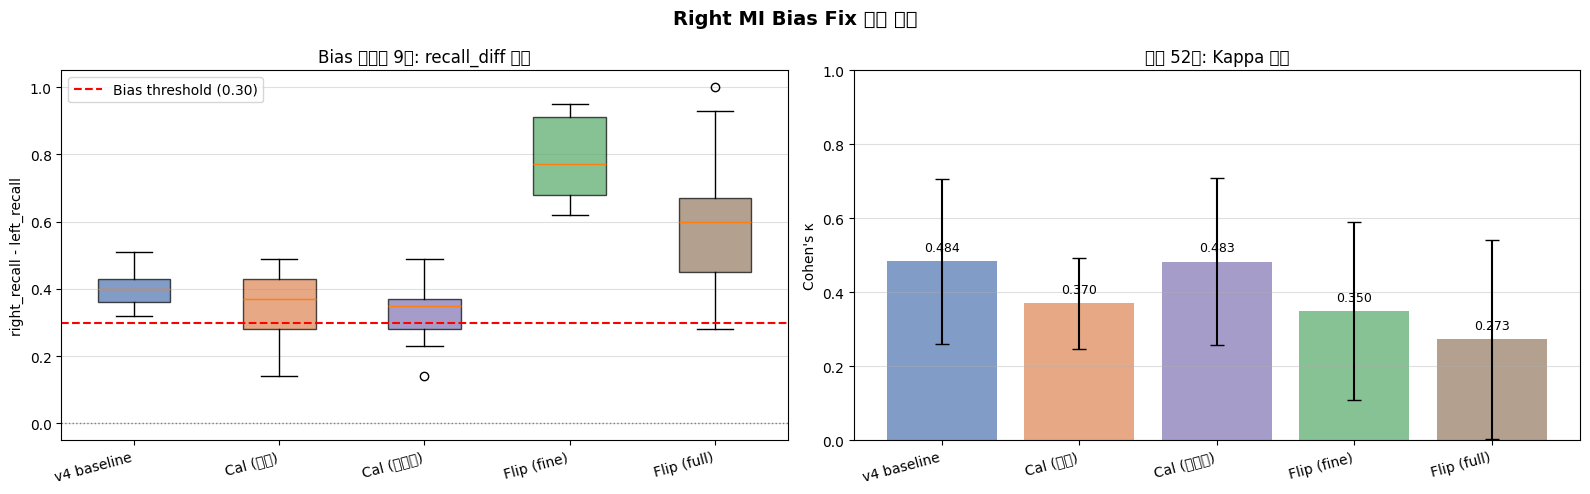

저장: /content/drive/MyDrive/BCI_Research/results/calibration/bias_fix_comparison.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

BCI_ROOT  = os.path.join(DRIVE_ROOT, 'BCI_Research')
cal_dir   = os.path.join(BCI_ROOT, 'results', 'calibration')
abl_dir   = os.path.join(BCI_ROOT, 'results', 'ablation')
BIAS_SIDS = [1, 5, 7, 11, 12, 15, 24, 34, 36]

def safe_read(path):
    return pd.read_csv(path) if os.path.exists(path) else None

cal_df      = safe_read(os.path.join(cal_dir, 'calibration_results.csv'))
cond_cal_df = safe_read(os.path.join(cal_dir, 'conditional_calibration_results.csv'))
flip_df     = safe_read(os.path.join(abl_dir, 'flip_aug_results.csv'))
flip_full_df = safe_read(os.path.join(abl_dir, 'flip_full_results.csv'))

# ── 전략별 recall_diff / kappa 수집 ──────────────────────────────
recall_strategies = {}
kappa_strategies  = {}

if cal_df is not None:
    b = cal_df[cal_df['sid'].isin(BIAS_SIDS)]
    recall_strategies['v4 baseline']  = b['right_recall_before'] - b['left_recall_before']
    recall_strategies['Cal (전체)']   = b['right_recall_after']  - b['left_recall_after']
    kappa_strategies['v4 baseline']   = cal_df['kappa_before']
    kappa_strategies['Cal (전체)']    = cal_df['kappa_after']

if cond_cal_df is not None:
    b = cond_cal_df[cond_cal_df['sid'].isin(BIAS_SIDS)]
    recall_strategies['Cal (조건부)'] = b['right_recall_after']  - b['left_recall_after']
    kappa_strategies['Cal (조건부)']  = cond_cal_df['kappa_after']

if flip_df is not None:
    b = flip_df[flip_df['sid'].isin(BIAS_SIDS)]
    recall_strategies['Flip (fine)'] = b['right_recall_flip'] - b['left_recall_flip']
    kappa_strategies['Flip (fine)']  = flip_df['kappa_flip']

if flip_full_df is not None:
    b = flip_full_df[flip_full_df['sid'].isin(BIAS_SIDS)]
    recall_strategies['Flip (full)'] = b['right_recall_flip'] - b['left_recall_flip']
    kappa_strategies['Flip (full)']  = flip_full_df['kappa_flip']

colors = ['#4C72B0', '#DD8452', '#8172B2', '#55A868', '#937860', '#C44E52']
n = max(len(recall_strategies), len(kappa_strategies))
pal = colors[:n]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: recall_diff boxplot (bias 피험자 9명)
ax = axes[0]
if recall_strategies:
    bp = ax.boxplot(list(recall_strategies.values()), patch_artist=True)
    for patch, color in zip(bp['boxes'], pal):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.axhline(0.30, color='red', linestyle='--', linewidth=1.5, label='Bias threshold (0.30)')
    ax.axhline(0.0,  color='gray', linestyle=':', linewidth=1)
    ax.set_xticks(range(1, len(recall_strategies)+1))
    ax.set_xticklabels(list(recall_strategies.keys()), rotation=15, ha='right')
    ax.set_ylabel('right_recall - left_recall')
    ax.set_title('Bias 피험자 9명: recall_diff 분포')
    ax.legend(); ax.grid(axis='y', alpha=0.4)

# 오른쪽: kappa 비교 (전체 52명)
ax2 = axes[1]
if kappa_strategies:
    means = [v.mean() for v in kappa_strategies.values()]
    stds  = [v.std()  for v in kappa_strategies.values()]
    x     = np.arange(len(kappa_strategies))
    bars  = ax2.bar(x, means, yerr=stds, capsize=5, color=pal[:len(kappa_strategies)], alpha=0.7)
    ax2.set_xticks(x)
    ax2.set_xticklabels(list(kappa_strategies.keys()), rotation=15, ha='right')
    ax2.set_ylabel("Cohen's κ")
    ax2.set_title('전체 52명: Kappa 비교')
    ax2.set_ylim(0, 1)
    ax2.grid(axis='y', alpha=0.4)
    for bar, mean in zip(bars, means):
        ax2.text(bar.get_x() + bar.get_width()/2, mean + 0.02,
                 f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Right MI Bias Fix 전략 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(cal_dir, 'bias_fix_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out_path}')
